In [1]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

In [2]:
BASE = Path("/home/natasha/multimodal_model")

# One root per split (do not reuse a single ROOT variable — each line would overwrite the last)
DATASETS = {
    "train": BASE / "outputs/train",
    "val": BASE / "outputs/val",
    "test": BASE / "outputs/test",
    "immrep_negatives": BASE / "outputs_data/immrep_test",
}

# JSON keys -> friendly column names
METRIC_MAP = {
    "confidence_score": "confidence_score",
    "ptm": "ptm",
    "iptm": "iptm",
    "complex_plddt": "plddt",
}

# Plot / filter thresholds (AF3-style: ipTM 0.6 confident interface; conf/plddt 0.7)
THRESHOLD_CONF = 0.7
THRESHOLD_IPTM = 0.6

IPTM_METRICS = {
    "iptm", "iptm_global", "iptm_pep_hla", "iptm_tcr_pep_mean",
    "iptm_tcrb_pep", "iptm_tcra_pep", "iptm_tcra_tcrb",
}


def metric_threshold(metric: str) -> float:
    return THRESHOLD_IPTM if metric in IPTM_METRICS or metric.startswith("iptm_") else THRESHOLD_CONF


CACHE = BASE / "scripts/analysis/boltz_confidence_scores.csv"
REBUILD_CACHE = False  # set True to rescan disk


def pair_id_from_conf_path(conf_path: Path) -> str:
    m = re.search(r"confidence_(.+)_model_0\.json$", conf_path.name)
    return m.group(1) if m else conf_path.parent.name


def confidence_rows_for_split(split: str, root: Path) -> pd.DataFrame:
    rows = []
    for conf_path in sorted(root.rglob("confidence_*_model_0.json")):
        data = json.loads(conf_path.read_text())
        row = {
            "split": split,
            "pair_id": pair_id_from_conf_path(conf_path),
            "in_predictions": "/predictions/" in str(conf_path),
            "conf_path": str(conf_path),
        }
        for json_key, col in METRIC_MAP.items():
            row[col] = data.get(json_key, np.nan)
        rows.append(row)
    df = pd.DataFrame(rows)
    df = df.sort_values(
        ["pair_id", "in_predictions", "confidence_score"],
        ascending=[True, False, False],
    )
    return df.drop_duplicates("pair_id", keep="first").reset_index(drop=True)


if CACHE.exists() and not REBUILD_CACHE:
    df_scores = pd.read_csv(CACHE)
    print(f"Loaded cache: {CACHE}")
else:
    dfs = []
    for split, root in DATASETS.items():
        print(f"Scanning {split} ...", flush=True)
        dfs.append(confidence_rows_for_split(split, root))
    df_scores = pd.concat(dfs, ignore_index=True)
    df_scores.to_csv(CACHE, index=False)
    print(f"Saved cache: {CACHE}")

print(df_scores.groupby("split").size())
df_scores.head()

Loaded cache: /home/natasha/multimodal_model/scripts/analysis/boltz_confidence_scores.csv
split
immrep_negatives     4000
test                 2190
train               31173
val                  1944
dtype: int64


,split,pair_id,in_predictions,conf_path,confidence_score,ptm,iptm,plddt
0,train,pair_000,False,/home/natasha/multimodal_model/outputs/train/c...,0.813786,0.799365,0.798340,0.817648
1,train,pair_002,False,/home/natasha/multimodal_model/outputs/train/c...,0.880897,0.891773,0.955089,0.862349
2,train,pair_003,False,/home/natasha/multimodal_model/outputs/train/c...,0.869157,0.861047,0.895447,0.862585
3,train,pair_004,False,/home/natasha/multimodal_model/outputs/train/c...,0.844011,0.856535,0.904602,0.828863
4,train,pair_005,False,/home/natasha/multimodal_model/outputs/train/c...,0.875892,0.848570,0.935674,0.860946


In [3]:
METRICS = list(METRIC_MAP.values())

# Summary stats per split
df_scores.groupby("split")[METRICS].describe().T

split                   immrep_negatives         test         train  \
confidence_score count       4000.000000  2190.000000  31173.000000   
                 mean           0.853779     0.833839      0.830765   
                 std            0.025860     0.035014      0.035029   
                 min            0.740269     0.718570      0.692778   
                 25%            0.842085     0.808166      0.804246   
                 50%            0.860940     0.838177      0.834021   
                 75%            0.871837     0.862210      0.859431   
                 max            0.909180     0.925251      0.931378   
ptm              count       4000.000000  2190.000000  31173.000000   
                 mean           0.857945     0.820637      0.810754   
                 std            0.063956     0.084588      0.087417   
                 min            0.491361     0.535102      0.486275   
                 25%            0.835305     0.770250      0.755340   
                 50%            0.872494     0.843947      0.833134   
                 75%            0.899933     0.885601      0.879002   
                 max            0.961107     0.970254      0.987457   
iptm             count       4000.000000  2190.000000  31173.000000   
                 mean           0.886666     0.828151      0.815762   
                 std            0.088117     0.114293      0.117399   
                 min            0.455210     0.506361      0.436984   
                 25%            0.850594     0.739016      0.722880   
                 50%            0.922662     0.857890      0.839614   
                 75%            0.948588     0.928183      0.920995   
                 max            0.980479     0.981758      0.987506   
plddt            count       4000.000000  2190.000000  31173.000000   
                 mean           0.845558     0.835261      0.834516   
                 std            0.015472     0.021884      0.021676   
                 min            0.788196     0.754702      0.731992   
                 25%            0.835683     0.821074      0.820578   
                 50%            0.846911     0.836379      0.836210   
                 75%            0.856307     0.851200      0.850174   
                 max            0.897386     0.912300      0.920118   

split                           val  
confidence_score count  1944.000000  
                 mean      0.833546  
                 std       0.035327  
                 min       0.740139  
                 25%       0.807108  
                 50%       0.837161  
                 75%       0.862215  
                 max       0.906738  
ptm              count  1944.000000  
                 mean      0.820547  
                 std       0.086811  
                 min       0.491245  
                 25%       0.769587  
                 50%       0.845682  
                 75%       0.885788  
                 max       0.974580  
iptm             count  1944.000000  
                 mean      0.827741  
                 std       0.116172  
                 min       0.475559  
                 25%       0.738153  
                 50%       0.856548  
                 75%       0.929793  
                 max       0.981054  
plddt            count  1944.000000  
                 mean      0.834997  
                 std       0.021987  
                 min       0.749410  
                 25%       0.820667  
                 50%       0.836731  
                 75%       0.851687  
                 max       0.891076

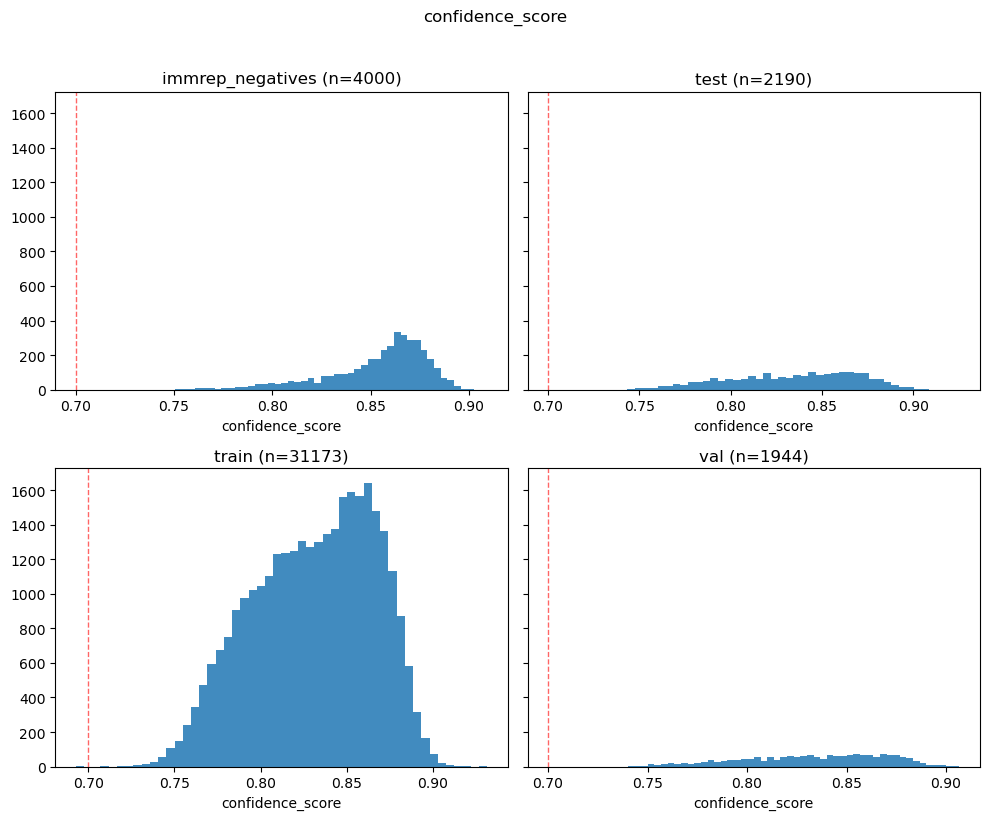

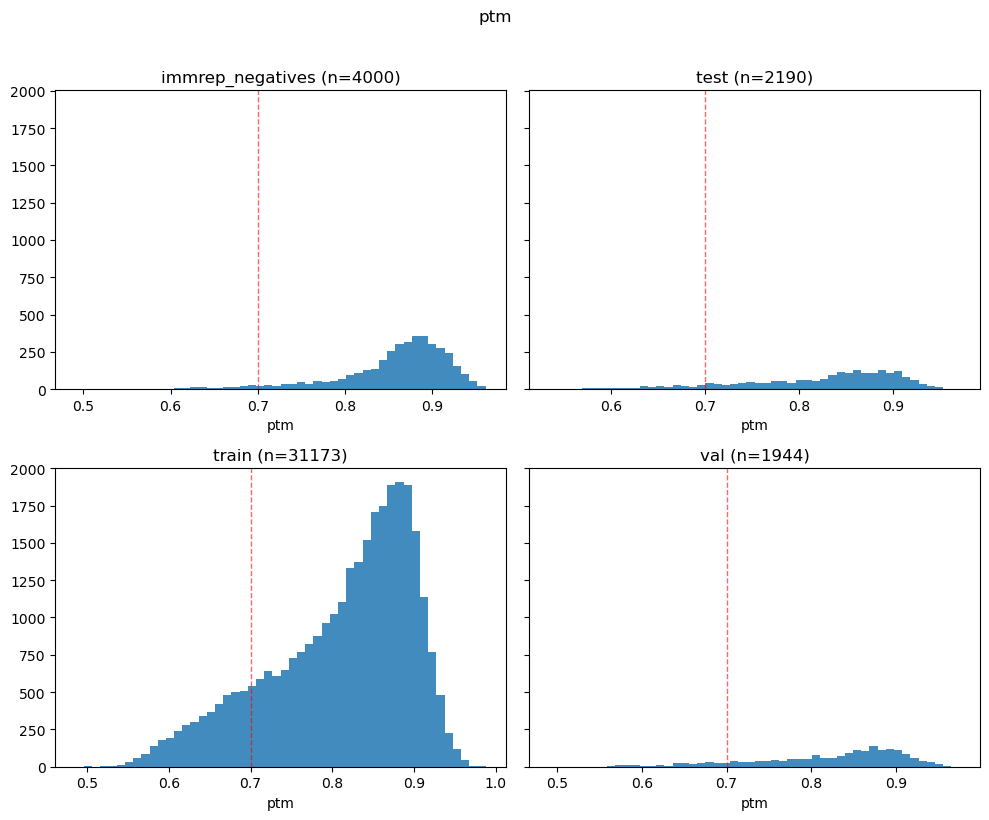

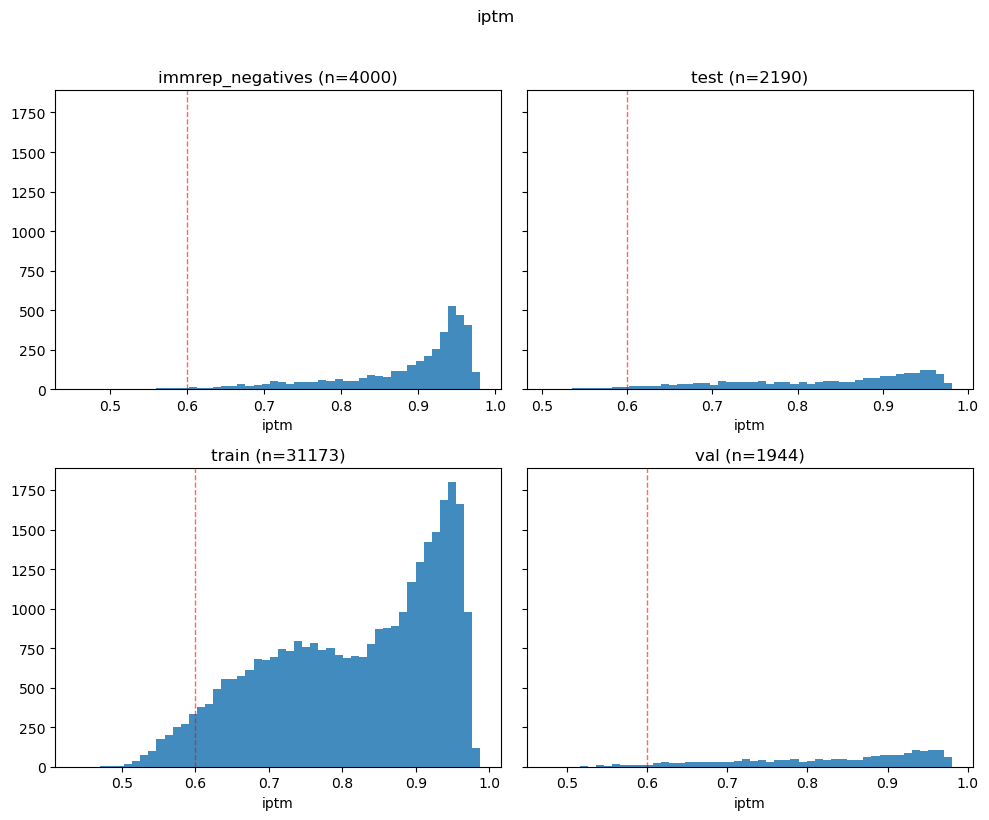

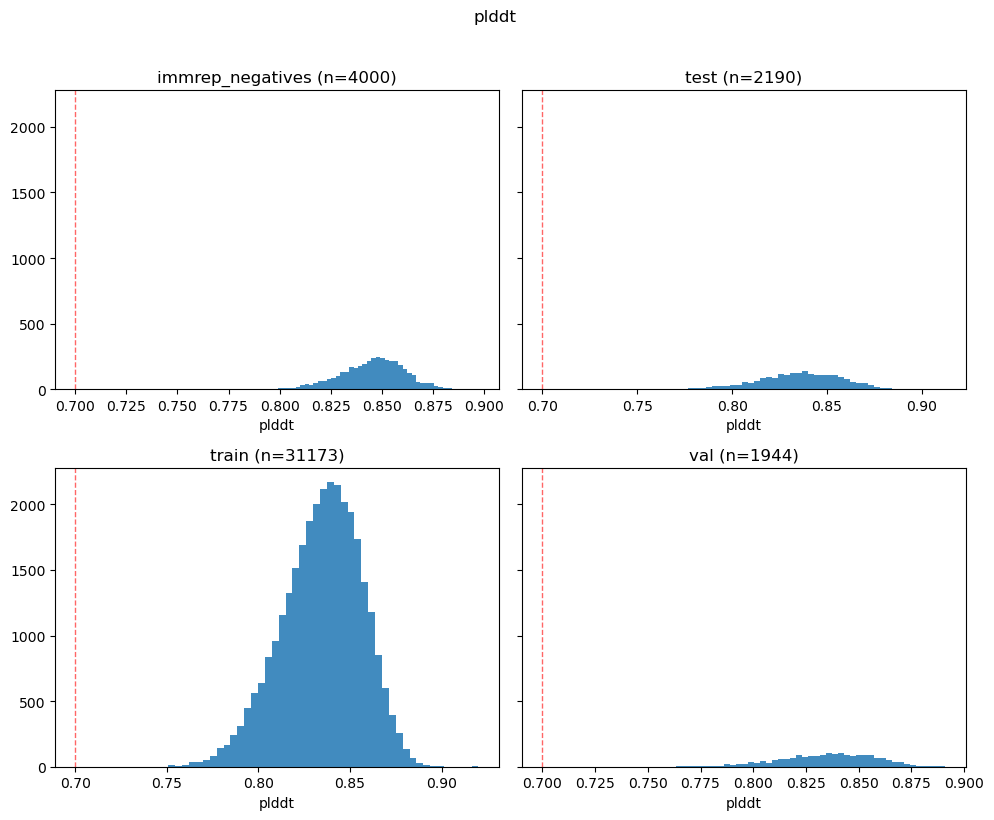

In [4]:
def plot_metric_by_split(df: pd.DataFrame, metric: str, *, bins: int = 50):
    splits = sorted(df["split"].unique())
    n = len(splits)
    ncols = 2
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, split in zip(axes, splits):
        sub = df.loc[df["split"] == split, metric].dropna()
        ax.hist(sub, bins=bins, alpha=0.85)
        thr = metric_threshold(metric)
        ax.axvline(thr, color="red", ls="--", lw=1, alpha=0.6)
        ax.set_title(f"{split} (n={len(sub)})")
        ax.set_xlabel(metric)
    for ax in axes[len(splits):]:
        ax.axis("off")
    fig.suptitle(metric, y=1.02)
    plt.tight_layout()
    plt.show()


for metric in METRICS:
    plot_metric_by_split(df_scores, metric)

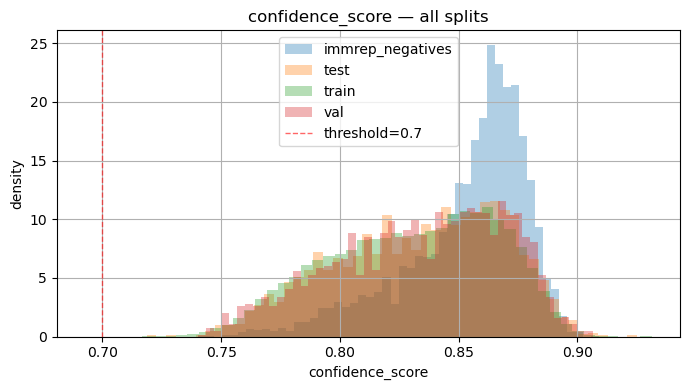

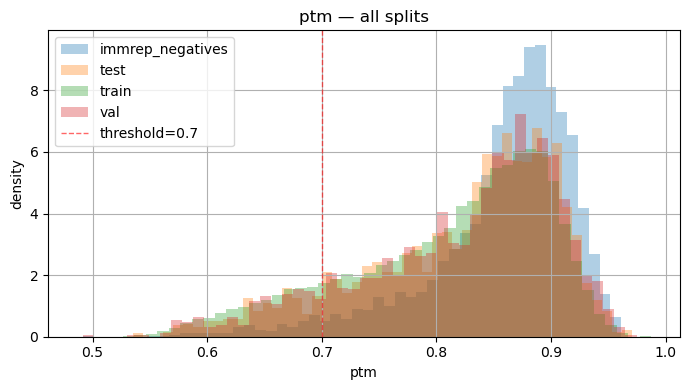

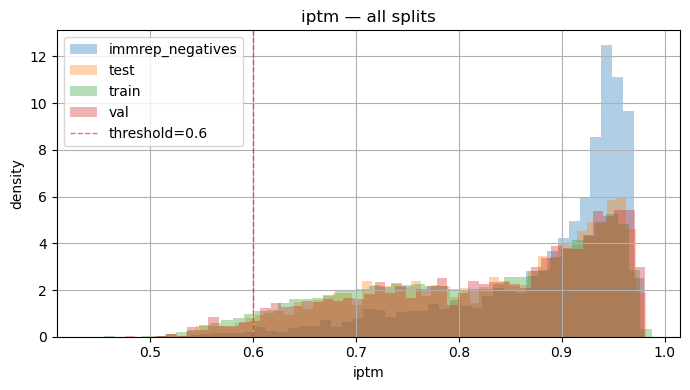

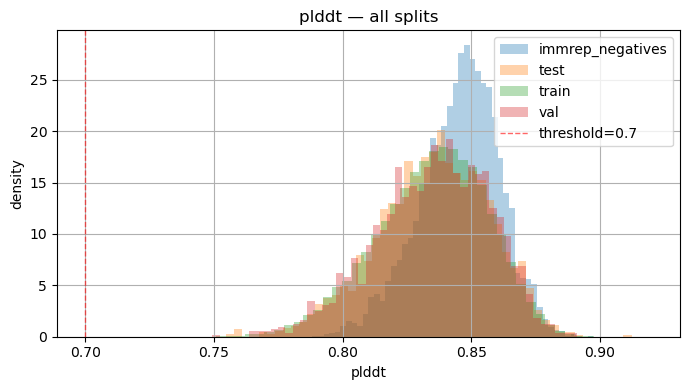

In [5]:
def plot_metric_overlay(df: pd.DataFrame, metric: str, *, bins: int = 50):
    plt.figure(figsize=(7, 4))
    thr = metric_threshold(metric)
    for split, sub in df.groupby("split"):
        sub[metric].dropna().hist(bins=bins, alpha=0.35, label=split, density=True)
    plt.xlabel(metric)
    plt.ylabel("density")
    plt.axvline(thr, color="red", ls="--", lw=1, alpha=0.6, label=f"threshold={thr}")
    plt.legend()
    plt.title(f"{metric} — all splits")
    plt.tight_layout()
    plt.show()


for metric in METRICS:
    plot_metric_overlay(df_scores, metric)

In [6]:
# --- Train low-confidence investigation ---
train = df_scores[df_scores["split"] == "train"].copy()
manifest = pd.read_csv(BASE / "manifests/train_manifest.csv")
train_m = train.merge(manifest, on="pair_id", how="left")

METRICS = list(METRIC_MAP.values())

def threshold_table(df: pd.DataFrame, metric: str, thresholds=(0.6, 0.7, 0.75, 0.8)):
    rows = []
    n = len(df)
    for t in thresholds:
        m = df[metric] < t
        rows.append({
            "metric": metric,
            "threshold": t,
            "count": int(m.sum()),
            "pct": 100 * m.mean(),
        })
    return pd.DataFrame(rows)

print(f"Train pairs: {len(train_m)}")
display(threshold_table(train_m, "confidence_score"))
display(threshold_table(train_m, "iptm"))
display(threshold_table(train_m, "ptm"))
display(threshold_table(train_m, "plddt"))

low_conf = train_m[train_m["confidence_score"] < THRESHOLD_CONF].sort_values("confidence_score")
print(f"\nconfidence_score < {THRESHOLD_CONF}: {len(low_conf)} pairs")
display(
    low_conf[
        [
            "pair_id", "confidence_score", "ptm", "iptm", "plddt",
            "pep_len", "tcra_len", "tcrb_len", "hla_len", "binding_flag", "conf_path",
        ]
    ]
)

Train pairs: 31173


,metric,threshold,count,pct
0,confidence_score,0.60,0,0.000000
1,confidence_score,0.70,1,0.003208
2,confidence_score,0.75,228,0.731402
3,confidence_score,0.80,6834,21.922818


,metric,threshold,count,pct
0,iptm,0.60,1403,4.500690
1,iptm,0.70,6300,20.209797
2,iptm,0.75,9676,31.039682
3,iptm,0.80,13059,41.892022


,metric,threshold,count,pct
0,ptm,0.60,584,1.873416
1,ptm,0.70,4329,13.887018
2,ptm,0.75,7396,23.725660
3,ptm,0.80,11621,37.279056


,metric,threshold,count,pct
0,plddt,0.60,0,0.000000
1,plddt,0.70,0,0.000000
2,plddt,0.75,3,0.009624
3,plddt,0.80,2151,6.900202



confidence_score < 0.7: 1 pairs


,pair_id,confidence_score,ptm,iptm,plddt,pep_len,tcra_len,tcrb_len,hla_len,binding_flag,conf_path
28969,pair_7945,0.692778,0.673764,0.436984,0.756726,12.0,0.0,120.0,365.0,1.0,/home/natasha/multimodal_model/outputs/train/c...


Loaded interface cache: /home/natasha/multimodal_model/scripts/analysis/boltz_interface_iptm_train.csv (31166 rows)
       confidence_score  iptm_global  iptm_pep_hla  iptm_tcra_pep  \
count         31166.000    31166.000     31166.000      30163.000   
mean              0.831        0.816         0.989          0.728   
std               0.035        0.117         0.005          0.200   
min               0.693        0.437         0.883          0.114   
25%               0.804        0.723         0.987          0.602   
50%               0.834        0.840         0.990          0.792   
75%               0.859        0.921         0.993          0.892   
max               0.919        0.988         0.998          0.979   

       iptm_tcrb_pep  iptm_tcra_tcrb  iptm_tcr_pep_mean  
count      27942.000       26939.000          31166.000  
mean           0.735           0.942              0.723  
std            0.198           0.035              0.202  
min            0.126          

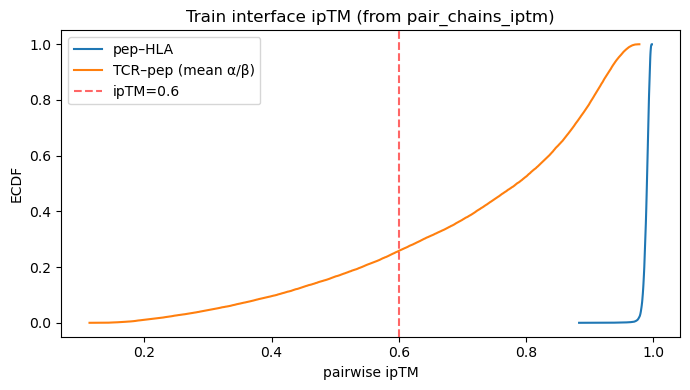

/tmp/ipykernel_2389128/2446687020.py:139: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


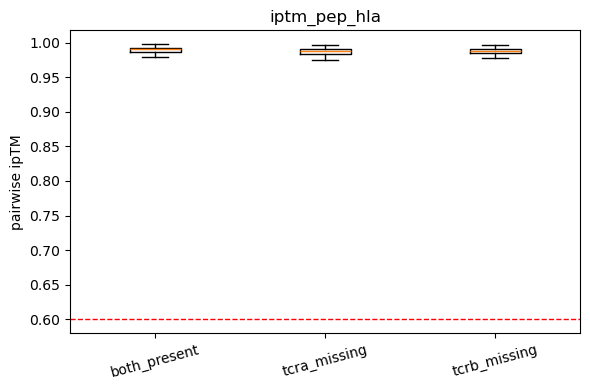

/tmp/ipykernel_2389128/2446687020.py:139: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


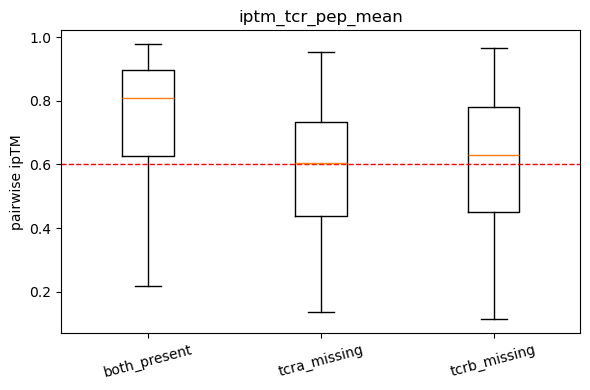

/tmp/ipykernel_2389128/2446687020.py:139: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


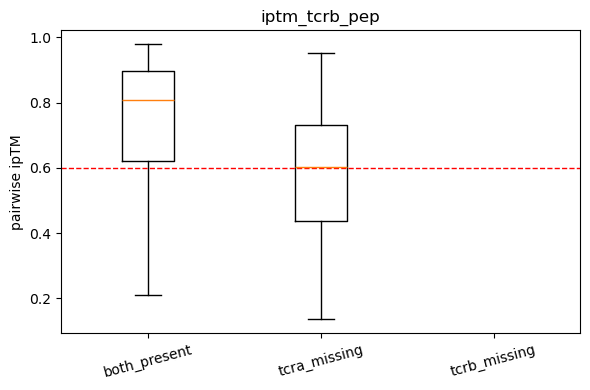

/tmp/ipykernel_2389128/2446687020.py:139: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


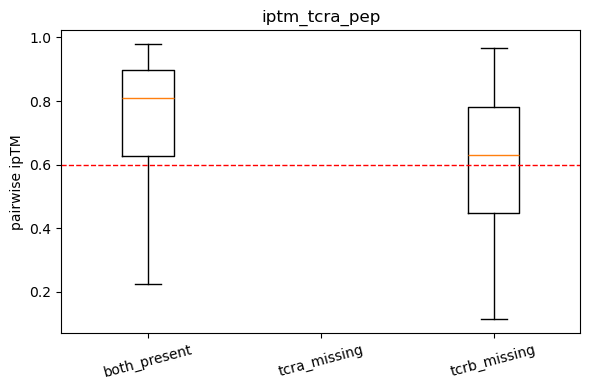

In [7]:
IFACE_CACHE = BASE / "scripts/analysis/boltz_interface_iptm_train.csv"
REBUILD_IFACE_CACHE = False


def resolve_yaml_path(row: pd.Series) -> Path | None:
    yp = row.get("yaml_path")
    if pd.notna(yp):
        p = BASE / str(yp)
        if p.exists():
            return p
    pid = str(row["pair_id"])
    for sub in (
        "data/train/_archive_root_yamls",
        "data/val/_archive_root_yamls",
        "data/test/_archive_root_yamls",
        "data/immrep_test/_archive_root_yamls",
    ):
        p = BASE / sub / f"{pid}.yaml"
        if p.exists():
            return p
    return None


def chain_names_from_yaml(yaml_path: Path) -> list[str]:
    doc = yaml.safe_load(yaml_path.read_text())
    names = []
    for seq in doc["sequences"]:
        msa = str(seq["protein"].get("msa", ""))
        if "tcra" in msa:
            names.append("tcra")
        elif "tcrb" in msa:
            names.append("tcrb")
        elif "mhc" in msa or "hla" in msa:
            names.append("hla")
        else:
            names.append("pep")
    return names


def pair_iptm(conf: dict, i: int, j: int) -> float:
    pci = conf["pair_chains_iptm"]
    return float(pci[str(i)][str(j)])


def interface_iptms(conf_path: Path, yaml_path: Path) -> dict:
    conf = json.loads(conf_path.read_text())
    if "pair_chains_iptm" not in conf:
        return {}
    names = chain_names_from_yaml(yaml_path)
    idx = {n: i for i, n in enumerate(names)}
    out = {}
    if "pep" in idx and "hla" in idx:
        out["iptm_pep_hla"] = pair_iptm(conf, idx["pep"], idx["hla"])
    if "tcra" in idx and "pep" in idx:
        out["iptm_tcra_pep"] = pair_iptm(conf, idx["tcra"], idx["pep"])
    if "tcrb" in idx and "pep" in idx:
        out["iptm_tcrb_pep"] = pair_iptm(conf, idx["tcrb"], idx["pep"])
    if "tcra" in idx and "tcrb" in idx:
        out["iptm_tcra_tcrb"] = pair_iptm(conf, idx["tcra"], idx["tcrb"])
    tcr_pep = [out[k] for k in ("iptm_tcra_pep", "iptm_tcrb_pep") if k in out]
    if tcr_pep:
        out["iptm_tcr_pep_mean"] = float(np.mean(tcr_pep))
    return out


def tcr_status_from_lens(tcra_len, tcrb_len) -> str:
    missing_tcra = tcra_len == 0
    missing_tcrb = tcrb_len == 0
    if missing_tcra and missing_tcrb:
        return "both_missing"
    if missing_tcra:
        return "tcra_missing"
    if missing_tcrb:
        return "tcrb_missing"
    return "both_present"


if IFACE_CACHE.exists() and not REBUILD_IFACE_CACHE:
    df_iface = pd.read_csv(IFACE_CACHE)
    print(f"Loaded interface cache: {IFACE_CACHE} ({len(df_iface)} rows)")
else:
    if "conf_path" not in train_m.columns:
        raise KeyError("train_m has no conf_path — re-run load cell with REBUILD_CACHE=True")

    rows = []
    skipped = 0
    for _, row in train_m.iterrows():
        conf_path = row.get("conf_path")
        if pd.isna(conf_path):
            skipped += 1
            continue
        yaml_path = resolve_yaml_path(row)
        if yaml_path is None:
            skipped += 1
            continue
        iface = interface_iptms(Path(str(conf_path)), yaml_path)
        if not iface:
            skipped += 1
            continue
        rows.append({
            "pair_id": row["pair_id"],
            "tcr_status": tcr_status_from_lens(row.get("tcra_len", 0), row.get("tcrb_len", 0)),
            "confidence_score": row.get("confidence_score"),
            "iptm_global": row.get("iptm"),
            **iface,
        })
    df_iface = pd.DataFrame(rows)
    df_iface.to_csv(IFACE_CACHE, index=False)
    print(f"Saved interface cache: {IFACE_CACHE} ({len(df_iface)} rows, skipped {skipped})")

print(df_iface.describe().round(3))

# ECDF: pep–MHC vs TCR–pep
fig, ax = plt.subplots(figsize=(7, 4))
for col, label in [("iptm_pep_hla", "pep–HLA"), ("iptm_tcr_pep_mean", "TCR–pep (mean α/β)")]:
    if col in df_iface.columns:
        x = np.sort(df_iface[col].dropna())
        ax.plot(x, np.arange(1, len(x) + 1) / len(x), label=label)
ax.axvline(THRESHOLD_IPTM, color="red", ls="--", alpha=0.6, label=f"ipTM={THRESHOLD_IPTM}")
ax.set_xlabel("pairwise ipTM")
ax.set_ylabel("ECDF")
ax.legend()
ax.set_title("Train interface ipTM (from pair_chains_iptm)")
plt.tight_layout()
plt.show()

# Boxplots by TCR chain completeness
iface_cols = [c for c in ["iptm_pep_hla", "iptm_tcr_pep_mean", "iptm_tcrb_pep", "iptm_tcra_pep"] if c in df_iface.columns]
if iface_cols and "tcr_status" in df_iface.columns:
    status_order = ["both_present", "tcra_missing", "tcrb_missing", "both_missing"]
    for col in iface_cols:
        groups = [
            df_iface.loc[df_iface["tcr_status"] == s, col].dropna().values
            for s in status_order
            if (df_iface["tcr_status"] == s).any()
        ]
        labels = [s for s in status_order if (df_iface["tcr_status"] == s).any()]
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.boxplot(groups, labels=labels, showfliers=False)
        ax.axhline(THRESHOLD_IPTM, color="red", ls="--", lw=1)
        ax.set_title(col)
        ax.set_ylabel("pairwise ipTM")
        plt.xticks(rotation=15)
        plt.tight_layout()
        plt.show()

Loaded all-splits interface cache: /home/natasha/multimodal_model/scripts/analysis/boltz_interface_iptm_all_splits.csv (39300 rows)

Rows per split:
split
immrep_negatives     4000
test                 2190
train               31166
val                  1944
dtype: int64


,iptm_global,iptm_pep_hla,iptm_tcr_pep_mean,iptm_tcra_pep,iptm_tcrb_pep
split,,,,,
train,0.816,0.989,0.723,0.728,0.735
val,0.828,0.990,0.740,0.744,0.754
test,0.828,0.990,0.740,0.744,0.758
immrep_negatives,0.887,0.992,0.844,0.846,0.842


,n,iptm_global,iptm_pep_hla,iptm_tcr_pep_mean,iptm_tcra_pep,iptm_tcrb_pep
split,,,,,,
train,31166,0.045,0.0,0.258,0.240,0.214
val,1944,0.036,0.0,0.227,0.215,0.178
test,2190,0.034,0.0,0.231,0.216,0.177
IMMREP negatives,4000,0.008,0.0,0.065,0.063,0.069


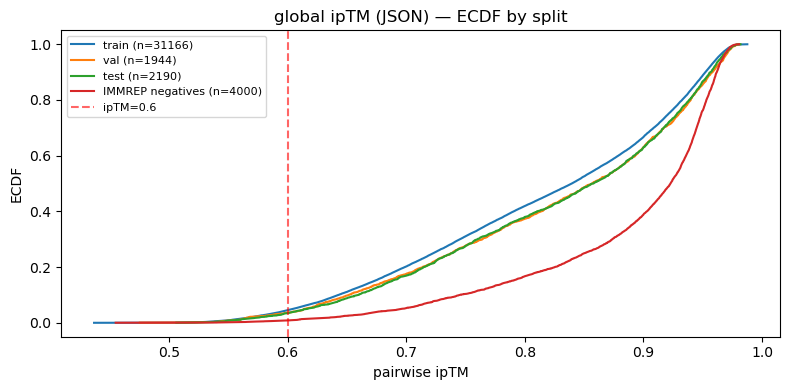

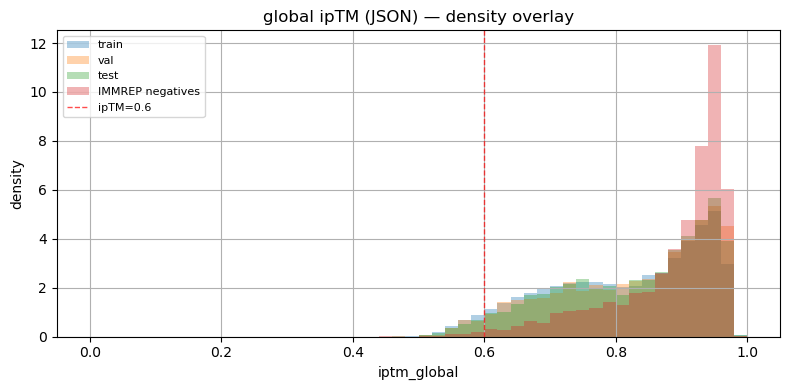

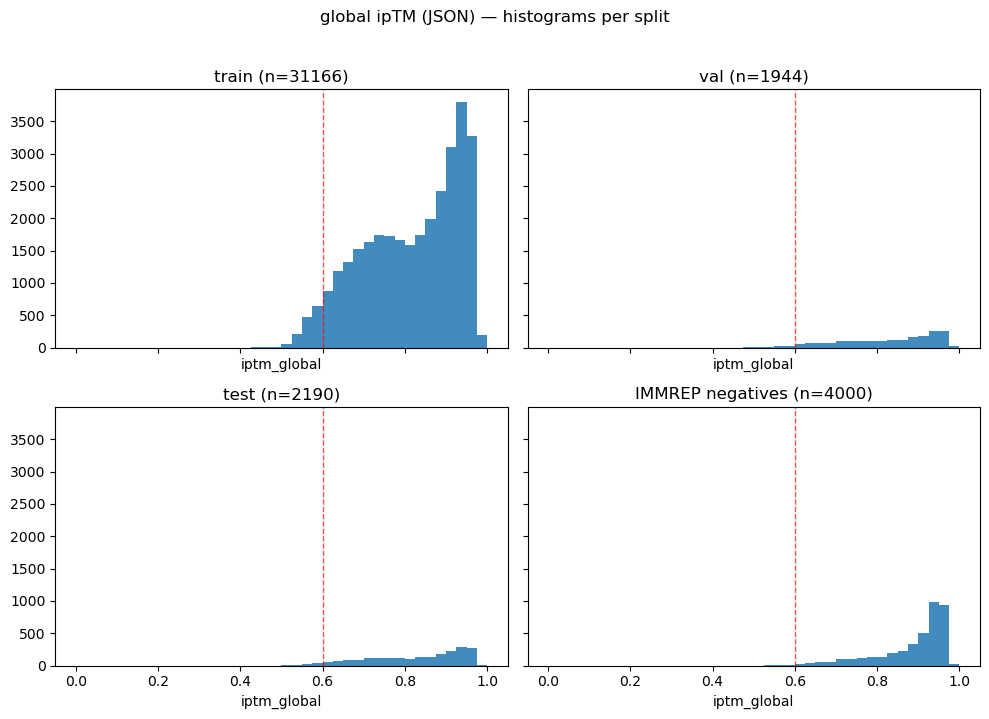

/tmp/ipykernel_2389128/3255053228.py:161: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


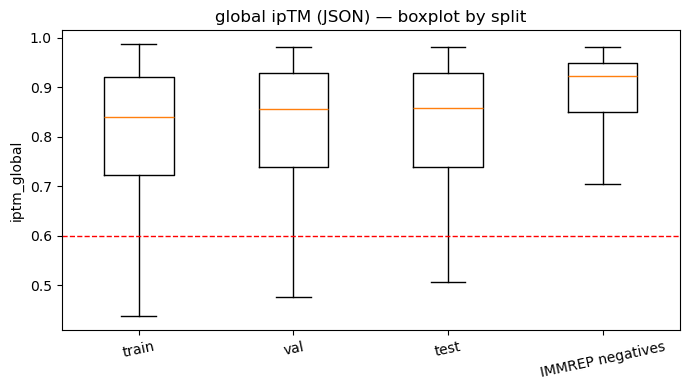

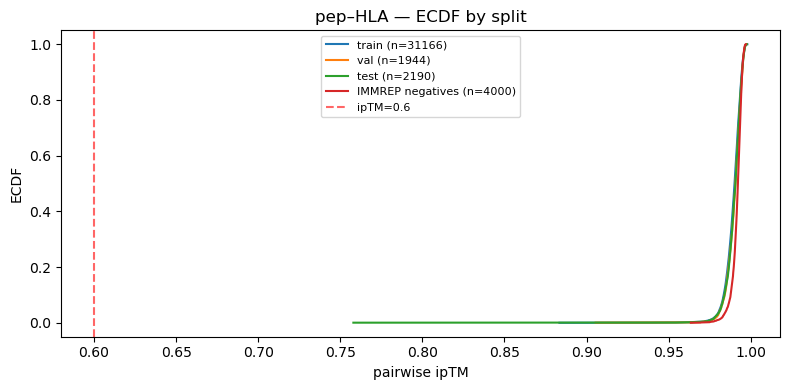

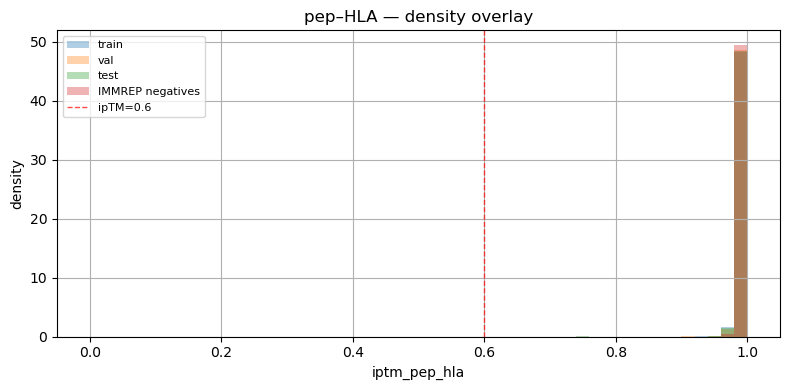

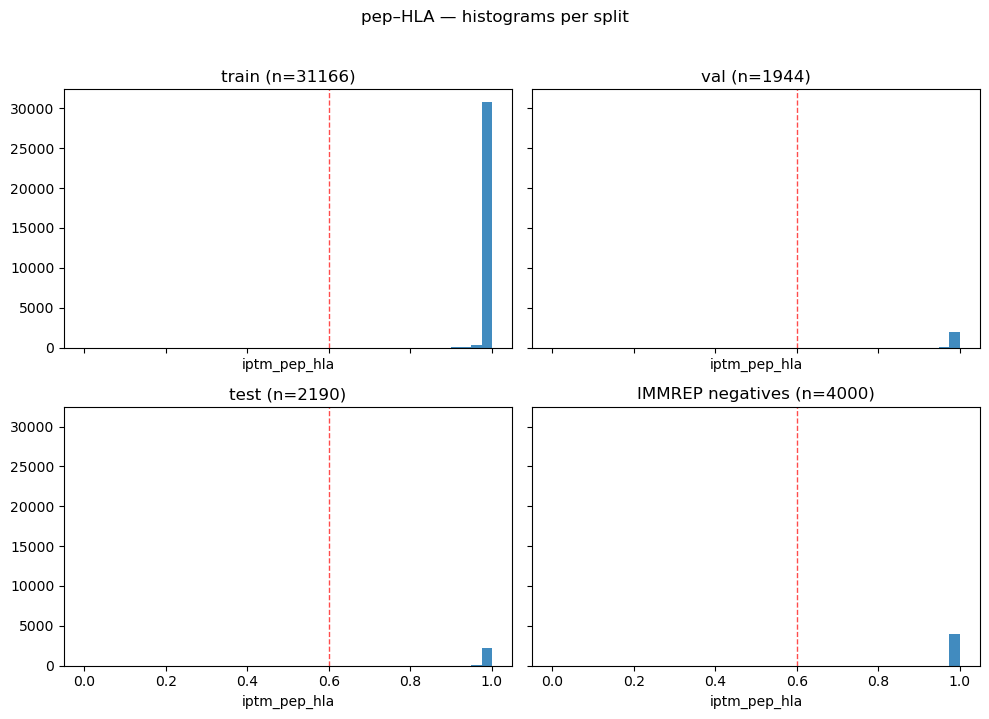

/tmp/ipykernel_2389128/3255053228.py:161: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


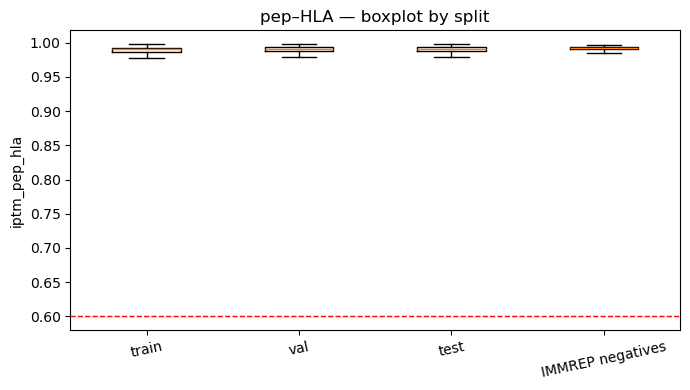

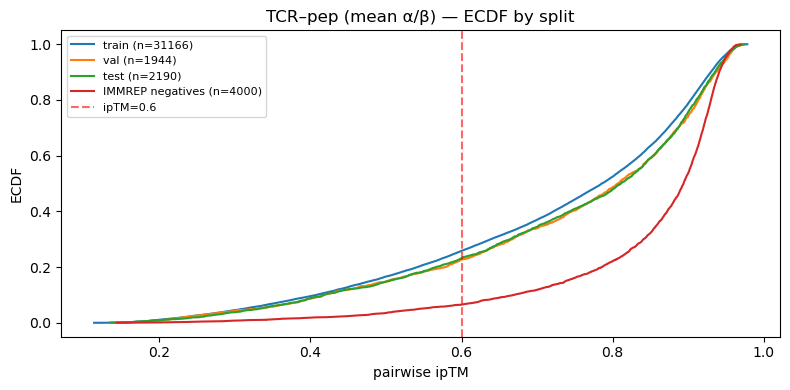

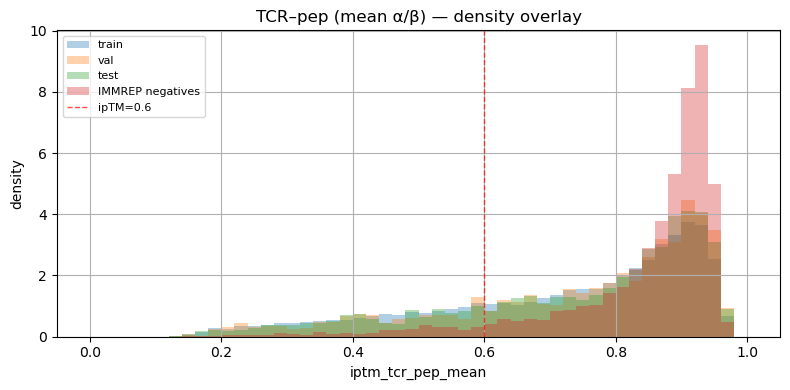

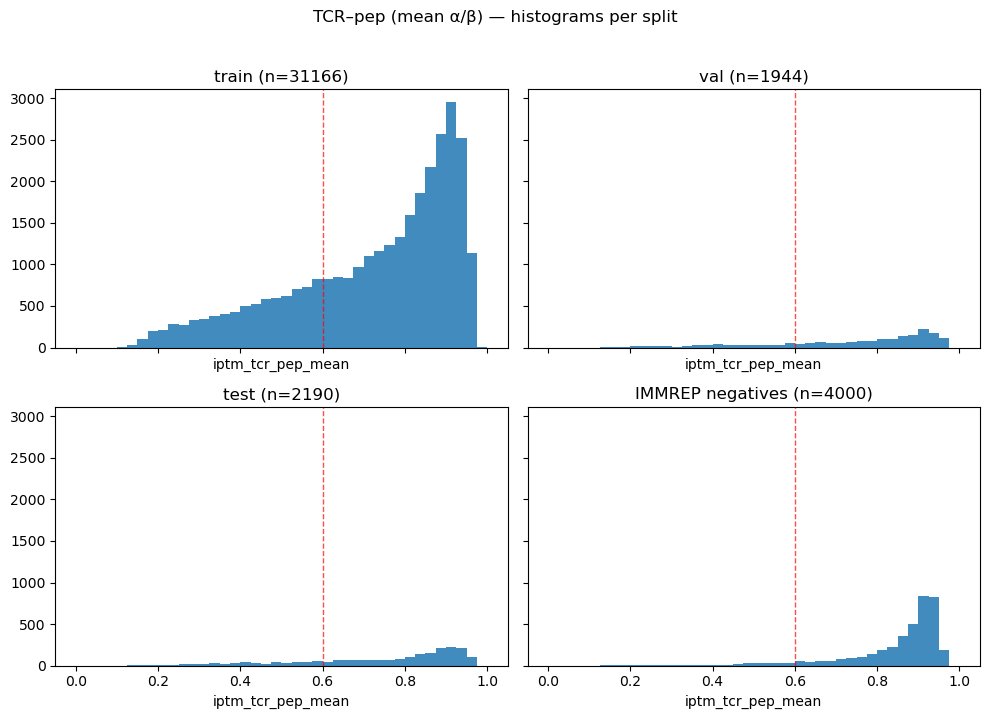

/tmp/ipykernel_2389128/3255053228.py:161: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


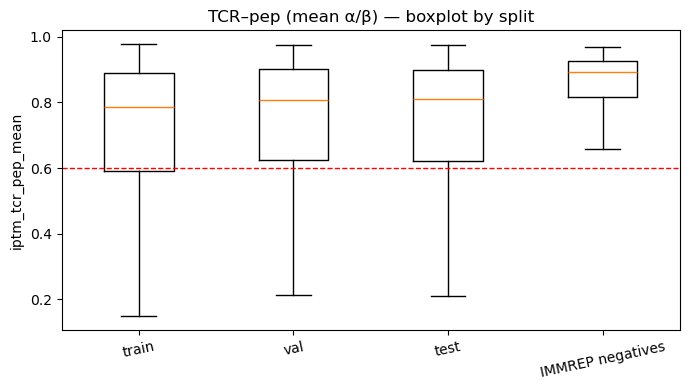

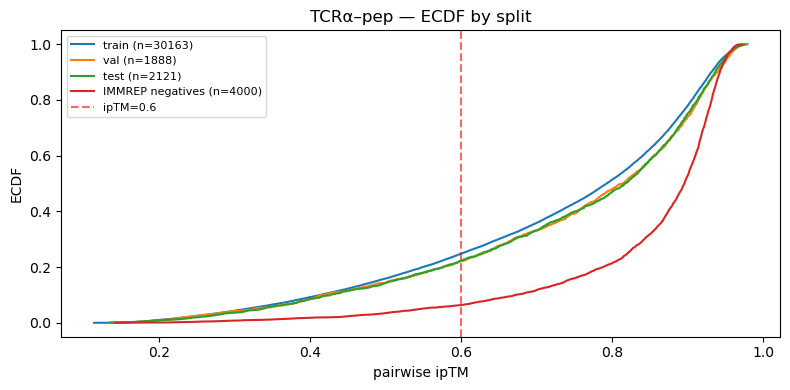

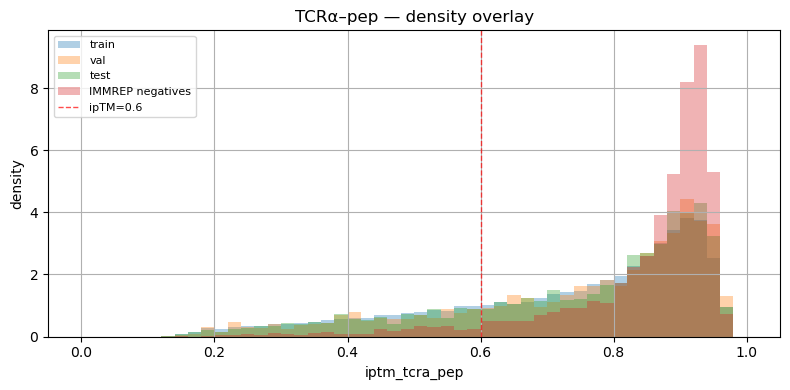

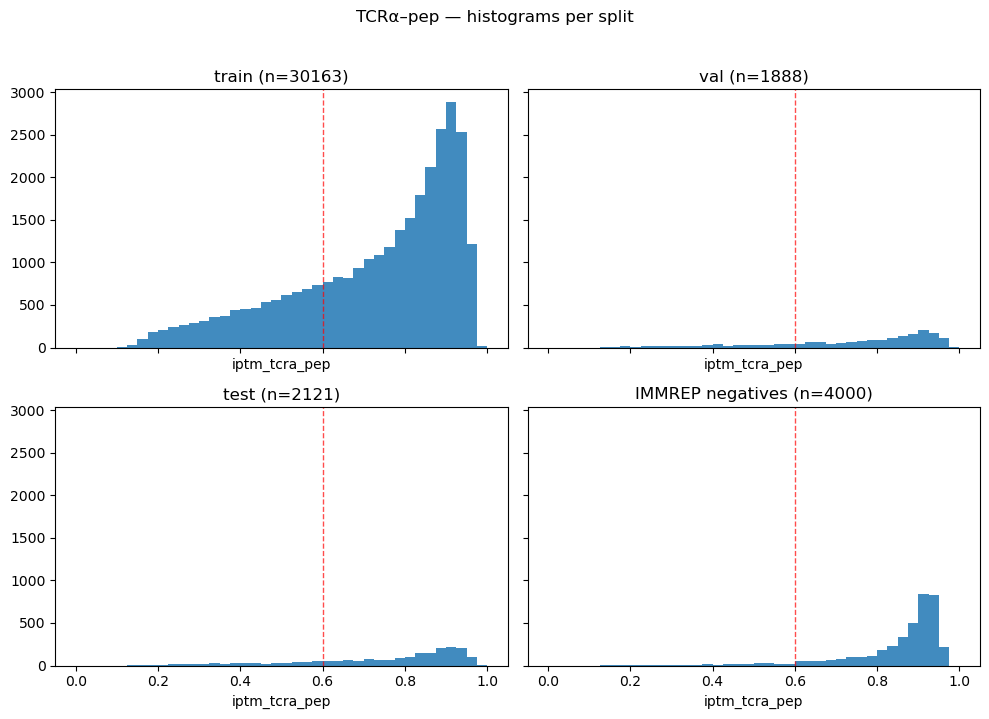

/tmp/ipykernel_2389128/3255053228.py:161: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


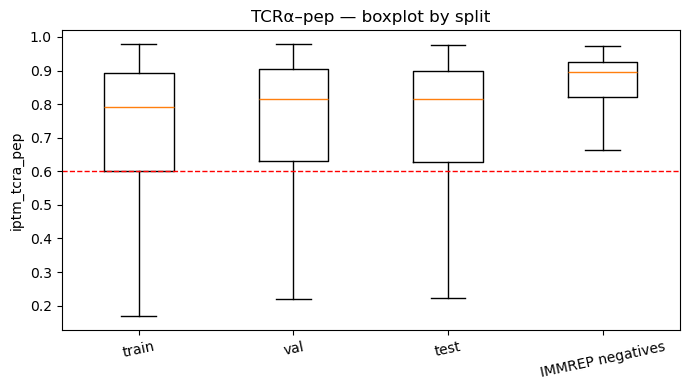

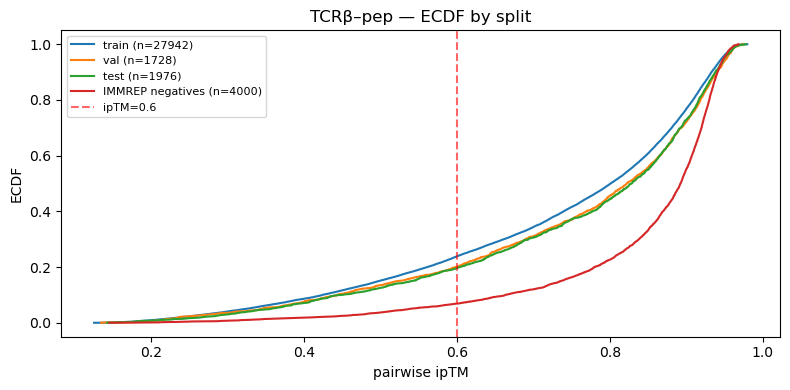

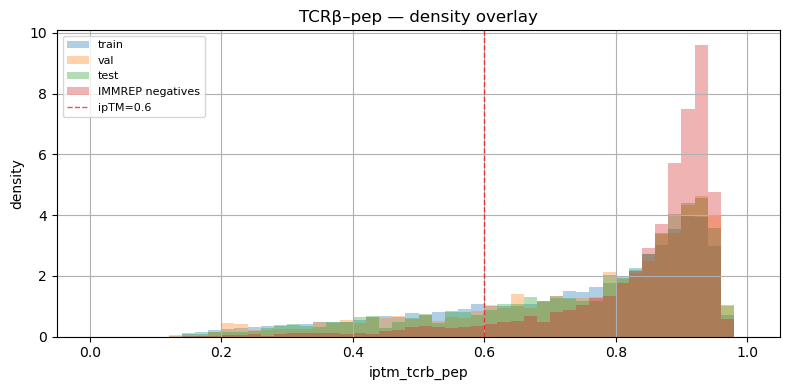

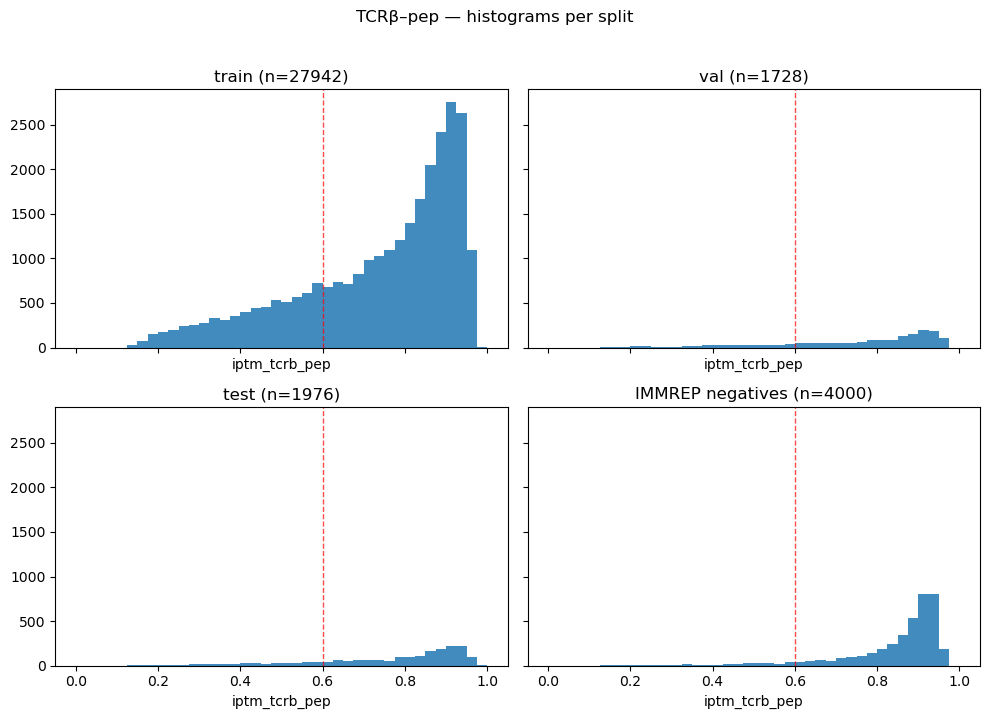

/tmp/ipykernel_2389128/3255053228.py:161: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


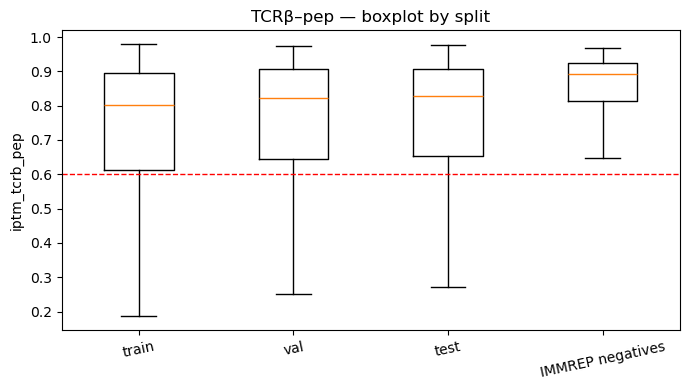

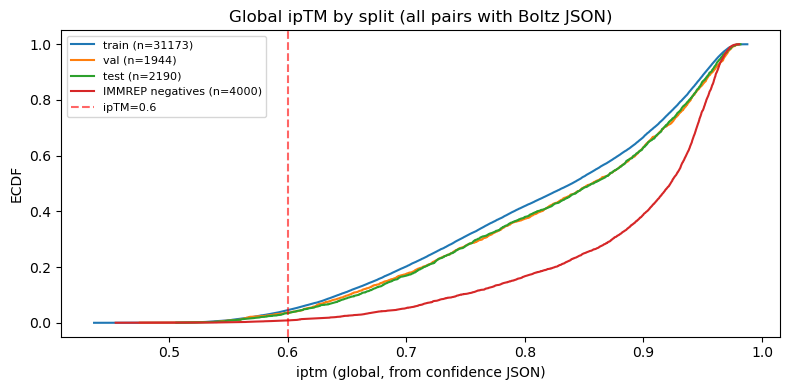

In [8]:
# --- Interface ipTM across splits (train / val / test vs IMMREP negatives) ---
IFACE_ALL_CACHE = BASE / "scripts/analysis/boltz_interface_iptm_all_splits.csv"
REBUILD_IFACE_ALL_CACHE = False

SPLIT_ORDER = ["train", "val", "test", "immrep_negatives"]
SPLIT_LABELS = {
    "train": "train",
    "val": "val",
    "test": "test",
    "immrep_negatives": "IMMREP negatives",
}
SPLIT_MANIFESTS = {
    "train": BASE / "manifests/train_manifest.csv",
    "val": BASE / "manifests/val_manifest.csv",
    "test": BASE / "manifests/test_manifest.csv",
    "immrep_negatives": BASE / "manifests/immrep_test_manifest.csv",
}

IFACE_METRICS = [
    ("iptm_global", "global ipTM (JSON)"),
    ("iptm_pep_hla", "pep–HLA"),
    ("iptm_tcr_pep_mean", "TCR–pep (mean α/β)"),
    ("iptm_tcra_pep", "TCRα–pep"),
    ("iptm_tcrb_pep", "TCRβ–pep"),
]


def merge_scores_with_manifest(split: str) -> pd.DataFrame:
    sub = df_scores.loc[df_scores["split"] == split].copy()
    manifest = pd.read_csv(SPLIT_MANIFESTS[split])
    return sub.merge(manifest, on="pair_id", how="left")


def build_iface_rows(df_m: pd.DataFrame, split: str) -> tuple[list[dict], int]:
    rows = []
    skipped = 0
    for _, row in df_m.iterrows():
        conf_path = row.get("conf_path")
        if pd.isna(conf_path):
            skipped += 1
            continue
        yaml_path = resolve_yaml_path(row)
        if yaml_path is None:
            skipped += 1
            continue
        iface = interface_iptms(Path(str(conf_path)), yaml_path)
        if not iface:
            skipped += 1
            continue
        rows.append({
            "split": split,
            "pair_id": row["pair_id"],
            "tcr_status": tcr_status_from_lens(row.get("tcra_len", 0), row.get("tcrb_len", 0)),
            "confidence_score": row.get("confidence_score"),
            "iptm_global": row.get("iptm"),
            **iface,
        })
    return rows, skipped


if IFACE_ALL_CACHE.exists() and not REBUILD_IFACE_ALL_CACHE:
    df_iface_all = pd.read_csv(IFACE_ALL_CACHE)
    print(f"Loaded all-splits interface cache: {IFACE_ALL_CACHE} ({len(df_iface_all)} rows)")
else:
    all_rows = []
    skip_by_split = {}
    for split in SPLIT_ORDER:
        df_m = merge_scores_with_manifest(split)
        rows, skipped = build_iface_rows(df_m, split)
        all_rows.extend(rows)
        skip_by_split[split] = skipped
        print(f"{split}: {len(rows)} iface rows, skipped {skipped} / {len(df_m)}")
    df_iface_all = pd.DataFrame(all_rows)
    df_iface_all.to_csv(IFACE_ALL_CACHE, index=False)
    print(f"Saved: {IFACE_ALL_CACHE}")

print("\nRows per split:")
print(df_iface_all.groupby("split").size())

# Summary means (quick table)
iface_value_cols = [c for c, _ in IFACE_METRICS if c in df_iface_all.columns]
summary_split = (
    df_iface_all.groupby("split")[iface_value_cols]
    .mean()
    .reindex(SPLIT_ORDER)
    .round(3)
)
display(summary_split)

# Fraction below AF3-style ipTM threshold per split
frac_lt = []
for split in SPLIT_ORDER:
    sub = df_iface_all[df_iface_all["split"] == split]
    if len(sub) == 0:
        continue
    row = {"split": SPLIT_LABELS[split], "n": len(sub)}
    for col in iface_value_cols:
        row[col] = (sub[col] < THRESHOLD_IPTM).mean()
    frac_lt.append(row)
display(pd.DataFrame(frac_lt).set_index("split").round(3))


def plot_iface_ecdf_overlay(df: pd.DataFrame, col: str, title: str):
    fig, ax = plt.subplots(figsize=(8, 4))
    for split in SPLIT_ORDER:
        sub = df.loc[df["split"] == split, col].dropna()
        if len(sub) == 0:
            continue
        x = np.sort(sub)
        ax.plot(
            x,
            np.arange(1, len(x) + 1) / len(x),
            label=f"{SPLIT_LABELS[split]} (n={len(sub)})",
        )
    ax.axvline(THRESHOLD_IPTM, color="red", ls="--", alpha=0.6, label=f"ipTM={THRESHOLD_IPTM}")
    ax.set_xlabel("pairwise ipTM")
    ax.set_ylabel("ECDF")
    ax.set_title(title)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_iface_hist_overlay(df: pd.DataFrame, col: str, title: str, *, bins: int = 50):
    fig, ax = plt.subplots(figsize=(8, 4))
    for split in SPLIT_ORDER:
        sub = df.loc[df["split"] == split, col].dropna()
        if len(sub) == 0:
            continue
        sub.hist(bins=bins, range=(0, 1), alpha=0.35, density=True, label=SPLIT_LABELS[split])
    ax.axvline(THRESHOLD_IPTM, color="red", ls="--", lw=1, alpha=0.7, label=f"ipTM={THRESHOLD_IPTM}")
    ax.set_xlabel(col)
    ax.set_ylabel("density")
    ax.set_title(title)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_iface_by_split(df: pd.DataFrame, col: str, title: str, *, bins: int = 40):
    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
    for ax, split in zip(axes.ravel(), SPLIT_ORDER):
        sub = df.loc[df["split"] == split, col].dropna()
        ax.hist(sub, bins=bins, range=(0, 1), alpha=0.85)
        ax.axvline(THRESHOLD_IPTM, color="red", ls="--", lw=1, alpha=0.7)
        ax.set_title(f"{SPLIT_LABELS[split]} (n={len(sub)})")
        ax.set_xlabel(col)
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_iface_boxplot_splits(df: pd.DataFrame, col: str, title: str):
    groups = [
        df.loc[df["split"] == s, col].dropna().values
        for s in SPLIT_ORDER
        if (df["split"] == s).any()
    ]
    labels = [SPLIT_LABELS[s] for s in SPLIT_ORDER if (df["split"] == s).any()]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.boxplot(groups, labels=labels, showfliers=False)
    ax.axhline(THRESHOLD_IPTM, color="red", ls="--", lw=1)
    ax.set_ylabel(col)
    ax.set_title(title)
    plt.xticks(rotation=12)
    plt.tight_layout()
    plt.show()


# --- Plots: overlay ECDF + density, then per-split panels, then boxplots ---
for col, label in IFACE_METRICS:
    if col not in df_iface_all.columns:
        continue
    plot_iface_ecdf_overlay(df_iface_all, col, f"{label} — ECDF by split")
    plot_iface_hist_overlay(df_iface_all, col, f"{label} — density overlay")
    plot_iface_by_split(df_iface_all, col, f"{label} — histograms per split")
    plot_iface_boxplot_splits(df_iface_all, col, f"{label} — boxplot by split")

# Global ipTM from df_scores (no YAML needed) — same split comparison
fig, ax = plt.subplots(figsize=(8, 4))
for split in SPLIT_ORDER:
    sub = df_scores.loc[df_scores["split"] == split, "iptm"].dropna()
    if len(sub) == 0:
        continue
    x = np.sort(sub)
    ax.plot(x, np.arange(1, len(x) + 1) / len(x), label=f"{SPLIT_LABELS[split]} (n={len(sub)})")
ax.axvline(THRESHOLD_IPTM, color="red", ls="--", alpha=0.6, label=f"ipTM={THRESHOLD_IPTM}")
ax.set_xlabel("iptm (global, from confidence JSON)")
ax.set_ylabel("ECDF")
ax.set_title("Global ipTM by split (all pairs with Boltz JSON)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


Loaded train: /home/natasha/multimodal_model/data/train/train_df_clean.csv | rows=31154 | cols=['pair_id', 'Peptide', 'HLA_sequence', 'TCR_full', 'binding_flag']
Loaded val: /home/natasha/multimodal_model/data/val/val_df_clean_pos_neg.csv | rows=3944 | cols=['pair_id', 'Peptide', 'HLA_sequence', 'TCR_full', 'binding_flag', 'pair_id_negative', 'TCRa', 'TCRb']
Loaded test: /home/natasha/multimodal_model/data/test/test_df_clean_pos_neg.csv | rows=4182 | cols=['pair_id', 'Peptide', 'HLA_sequence', 'TCR_full', 'binding_flag', 'pair_id_negative', 'TCRa', 'TCRb']
Loaded immrep_negatives: /home/natasha/multimodal_model/data/immrep_test/immrep_negative_reloc_map.csv | rows=4000 | cols=['immrep_pair_id', 'legacy_pair_id', 'from_test', 'from_val', 'pair_id_negative', 'Peptide', 'HLA_sequence', 'TCR_full', 'binding_flag', 'immrep_chunk', 'old_yaml_path', 'old_msa_dir', 'old_boltz_dir', 'new_yaml_path', 'new_chunk_yaml_path', 'new_msa_dir', 'new_boltz_dir', 'relocate_status']

Using columns:
  pep_

split
immrep_negatives     4000
test                 2190
train               31166
val                  1944
dtype: int64


Metadata missingness:


,missing_tcr,missing_pep,missing_pmhc
split,,,
immrep_negatives,0.000,0.000,0.000
test,0.004,0.004,0.004
train,0.000,0.000,0.000
val,0.000,0.000,0.000



Created residual columns:
['iptm_global_resid_tcr_pmhc', 'iptm_global_resid_tcr_pep', 'iptm_pep_hla_resid_tcr_pmhc', 'iptm_pep_hla_resid_tcr_pep', 'iptm_tcr_pep_mean_resid_tcr_pmhc', 'iptm_tcr_pep_mean_resid_tcr_pep', 'iptm_tcra_pep_resid_tcr_pmhc', 'iptm_tcra_pep_resid_tcr_pep', 'iptm_tcrb_pep_resid_tcr_pmhc', 'iptm_tcrb_pep_resid_tcr_pep']


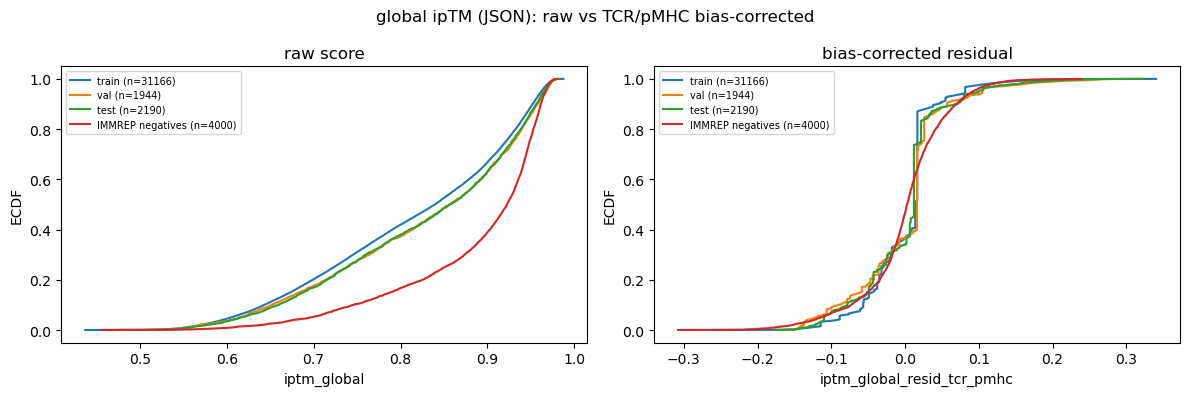

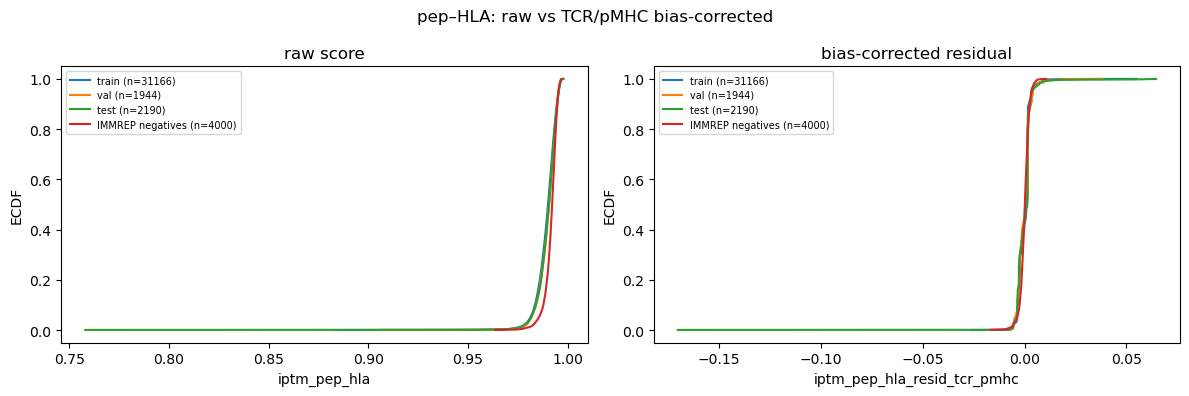

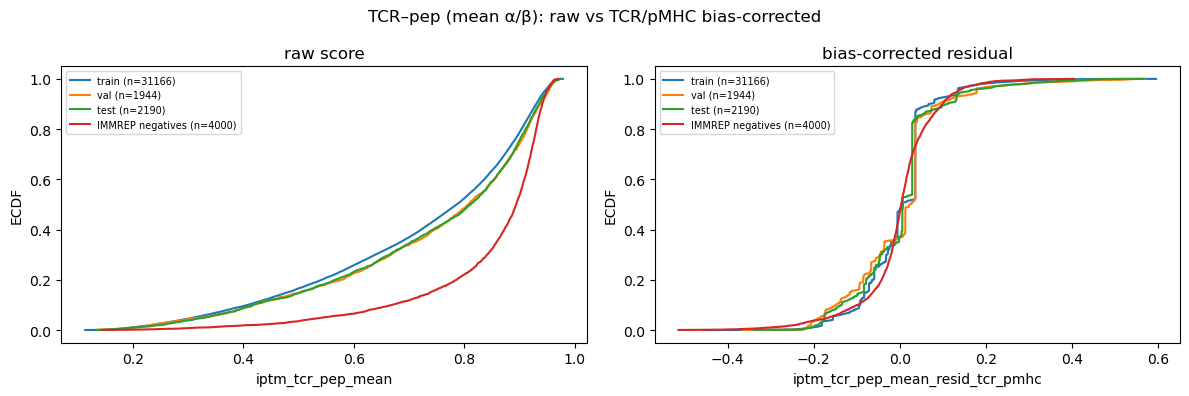

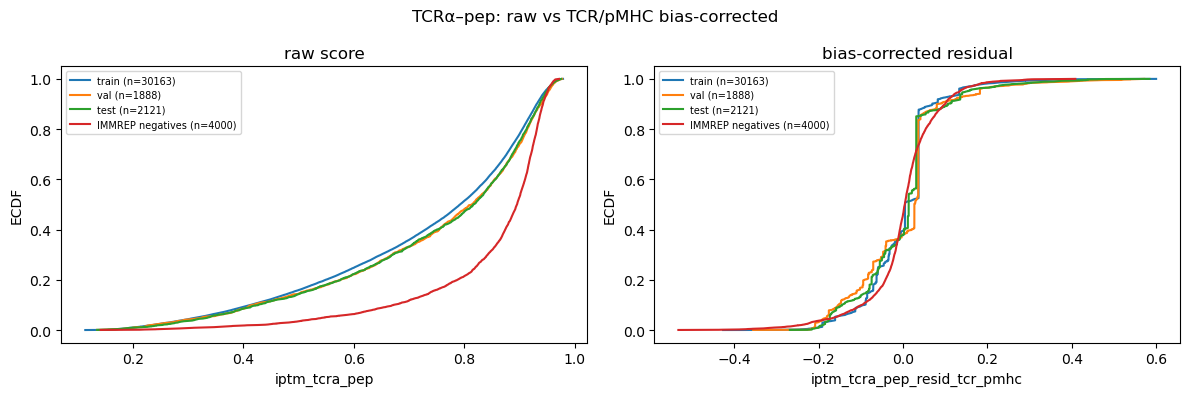

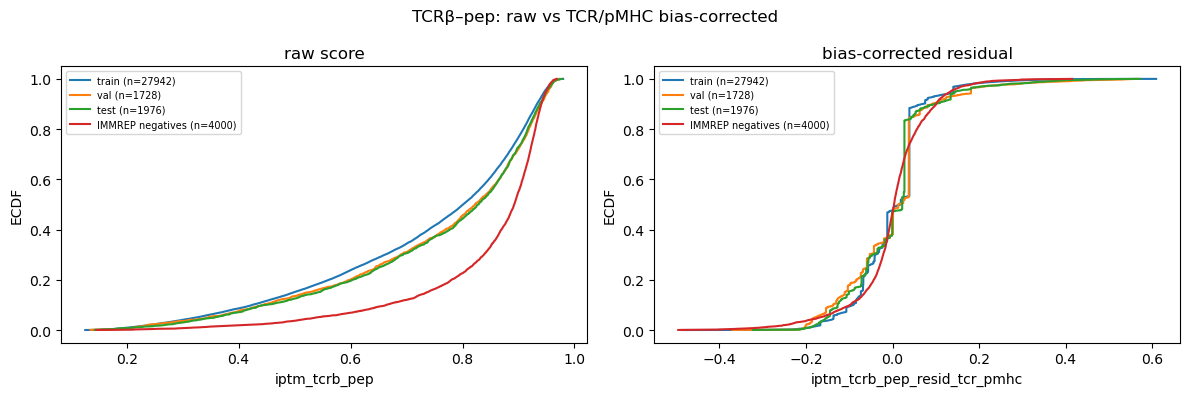


Signal table:


""



Saved corrected scores: /home/natasha/multimodal_model/scripts/analysis/boltz_interface_bias_corrected_scores.csv
Saved signal table:     /home/natasha/multimodal_model/scripts/analysis/boltz_interface_bias_corrected_signal_table.csv


In [14]:
# ============================================================
# One-cell Boltz bias-correction audit
# Correctly handles IMMREP negatives via immrep_pair_id -> pair_id
# Run AFTER df_iface_all has been created/loaded.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.stats import mannwhitneyu

# -----------------------------
# Helpers
# -----------------------------

def first_existing_col(df, candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand in df.columns:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None


def load_split_metadata():
    csv_paths = {
        "train": BASE / "data/train/train_df_clean.csv",
        "val": BASE / "data/val/val_df_clean_pos_neg.csv",
        "test": BASE / "data/test/test_df_clean_pos_neg.csv",
        "immrep_negatives": BASE / "data/immrep_test/immrep_negative_reloc_map.csv",
    }

    frames = []

    for split, path in csv_paths.items():
        if not path.exists():
            print(f"[WARN] Missing metadata file for {split}: {path}")
            continue

        m = pd.read_csv(path)
        print(f"Loaded {split}: {path} | rows={len(m)} | cols={list(m.columns)}")

        # Key fix: IMMREP negative file uses immrep_pair_id, not pair_id.
        if split == "immrep_negatives":
            if "immrep_pair_id" in m.columns:
                m = m.rename(columns={"immrep_pair_id": "pair_id"})
            elif "pair_id" not in m.columns:
                raise ValueError(
                    "IMMREP negative metadata has neither immrep_pair_id nor pair_id."
                )

        if "pair_id" not in m.columns:
            raise ValueError(f"No pair_id column found for split={split}: {path}")

        m["split"] = split

        keep = ["split", "pair_id"]
        for c in [
            "Peptide", "peptide", "pep",
            "HLA_sequence", "hla_sequence", "hla", "HLA",
            "TCR_full", "tcr_full", "TCR", "tcr",
            "binding_flag", "label", "target", "binder", "is_binder",
        ]:
            if c in m.columns and c not in keep:
                keep.append(c)

        frames.append(m[keep].drop_duplicates(["split", "pair_id"]))

    if not frames:
        raise ValueError("No metadata files loaded.")

    return pd.concat(frames, ignore_index=True)


def enrich_iface_with_metadata(df_iface_all):
    df = df_iface_all.copy()

    # Drop stale metadata columns from previous failed runs.
    stale_cols = [
        "Peptide", "peptide", "pep",
        "HLA_sequence", "hla_sequence", "hla", "HLA",
        "TCR_full", "tcr_full", "TCR", "tcr",
        "binding_flag", "label", "target", "binder", "is_binder",
        "tcr_id", "pep_id", "pmhc_id",
    ]
    df = df.drop(columns=[c for c in stale_cols if c in df.columns], errors="ignore")

    meta = load_split_metadata()
    df = df.merge(meta, on=["split", "pair_id"], how="left")

    return df


def add_pairing_ids(df):
    df = df.copy()

    pep_col = first_existing_col(df, ["Peptide", "peptide", "pep"])
    hla_col = first_existing_col(df, ["HLA_sequence", "hla_sequence", "hla", "HLA"])
    tcr_col = first_existing_col(df, ["TCR_full", "tcr_full", "TCR", "tcr"])
    label_col = first_existing_col(df, ["binding_flag", "label", "target", "binder", "is_binder"])

    print("\nUsing columns:")
    print("  pep_col  :", pep_col)
    print("  hla_col  :", hla_col)
    print("  tcr_col  :", tcr_col)
    print("  label_col:", label_col)

    if pep_col is None:
        raise ValueError("Could not find peptide column after metadata merge.")
    if tcr_col is None:
        raise ValueError("Could not find TCR_full column after metadata merge.")

    df["tcr_id"] = df[tcr_col].fillna("MISSING_TCR").astype(str)
    df["pep_id"] = df[pep_col].fillna("MISSING_PEP").astype(str)

    if hla_col is not None:
        df["pmhc_id"] = (
            df[pep_col].fillna("MISSING_PEP").astype(str)
            + "|"
            + df[hla_col].fillna("MISSING_HLA").astype(str)
        )
    else:
        df["pmhc_id"] = df["pep_id"]

    return df, label_col


def two_way_bias_correct(df, score_col, row_col="tcr_id", col_col="pmhc_id", group_col="split"):
    """
    residual = score - TCR_mean - peptide/HLA_mean + split_mean

    Residuals are not ipTM scores anymore.
    They can be negative or positive.
    """
    out = pd.Series(index=df.index, dtype=float)

    for split, g in df.groupby(group_col):
        x = pd.to_numeric(g[score_col], errors="coerce")
        valid = x.notna()

        gg = g.loc[valid]
        xx = x.loc[valid]

        if len(gg) == 0:
            continue

        grand = xx.mean()
        row_mean = xx.groupby(gg[row_col]).mean()
        col_mean = xx.groupby(gg[col_col]).mean()

        out.loc[gg.index] = (
            xx
            - gg[row_col].map(row_mean)
            - gg[col_col].map(col_mean)
            + grand
        )

    return out


def audit_metric_signal(df, metrics, label_col):
    rows = []

    if label_col is None:
        print("[WARN] No label column found. Skipping AUROC/AUPRC table.")
        return pd.DataFrame()

    for split, g in df.groupby("split"):
        y_all = pd.to_numeric(g[label_col], errors="coerce")

        for metric in metrics:
            if metric not in g.columns:
                continue

            x_all = pd.to_numeric(g[metric], errors="coerce")
            valid = x_all.notna() & y_all.notna()

            if valid.sum() < 10:
                continue

            x = x_all[valid]
            y = y_all[valid].astype(int)

            if y.nunique() < 2:
                continue

            pos = x[y == 1]
            neg = x[y == 0]

            try:
                auroc = roc_auc_score(y, x)
                auprc = average_precision_score(y, x)
                _, p = mannwhitneyu(pos, neg, alternative="two-sided")
            except Exception:
                continue

            rows.append({
                "split": split,
                "metric": metric,
                "n": len(x),
                "n_pos": int((y == 1).sum()),
                "n_neg": int((y == 0).sum()),
                "pos_median": float(pos.median()),
                "neg_median": float(neg.median()),
                "delta_pos_minus_neg": float(pos.median() - neg.median()),
                "auroc_pos_high": float(auroc),
                "auprc_pos_high": float(auprc),
                "mannwhitney_p": float(p),
            })

    if not rows:
        return pd.DataFrame()

    return (
        pd.DataFrame(rows)
        .sort_values(["split", "auroc_pos_high"], ascending=[True, False])
        .reset_index(drop=True)
    )


def plot_raw_vs_residual(df, raw_col, resid_col, label):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, col, subtitle in zip(
        axes,
        [raw_col, resid_col],
        ["raw score", "bias-corrected residual"],
    ):
        for split in SPLIT_ORDER:
            sub = pd.to_numeric(df.loc[df["split"] == split, col], errors="coerce").dropna()
            if len(sub) == 0:
                continue

            x = np.sort(sub.values)
            y = np.arange(1, len(x) + 1) / len(x)
            ax.plot(x, y, label=f"{SPLIT_LABELS[split]} (n={len(sub)})")

        ax.set_title(subtitle)
        ax.set_xlabel(col)
        ax.set_ylabel("ECDF")
        ax.legend(fontsize=7)

    fig.suptitle(label)
    plt.tight_layout()
    plt.show()


# -----------------------------
# Run correction
# -----------------------------

df_bias = enrich_iface_with_metadata(df_iface_all)
df_bias, label_col = add_pairing_ids(df_bias)

print("\nRows per split after metadata merge:")
display(df_bias.groupby("split").size())

print("\nMetadata missingness:")
missingness = (
    df_bias.assign(
        missing_tcr=df_bias["tcr_id"].eq("MISSING_TCR"),
        missing_pep=df_bias["pep_id"].eq("MISSING_PEP"),
        missing_pmhc=df_bias["pmhc_id"].str.contains("MISSING", na=True),
    )
    .groupby("split")[["missing_tcr", "missing_pep", "missing_pmhc"]]
    .mean()
    .round(3)
)
display(missingness)

metric_cols = [c for c, _ in IFACE_METRICS if c in df_bias.columns]

for col in metric_cols:
    df_bias[f"{col}_resid_tcr_pmhc"] = two_way_bias_correct(
        df_bias,
        score_col=col,
        row_col="tcr_id",
        col_col="pmhc_id",
        group_col="split",
    )

    df_bias[f"{col}_resid_tcr_pep"] = two_way_bias_correct(
        df_bias,
        score_col=col,
        row_col="tcr_id",
        col_col="pep_id",
        group_col="split",
    )

print("\nCreated residual columns:")
print([c for c in df_bias.columns if "_resid_" in c])


# -----------------------------
# Plots
# -----------------------------

for col, label in IFACE_METRICS:
    resid_col = f"{col}_resid_tcr_pmhc"
    if col in df_bias.columns and resid_col in df_bias.columns:
        plot_raw_vs_residual(
            df_bias,
            raw_col=col,
            resid_col=resid_col,
            label=f"{label}: raw vs TCR/pMHC bias-corrected"
        )


# -----------------------------
# Signal table
# -----------------------------

raw_and_corrected = []
for col in metric_cols:
    raw_and_corrected.extend([
        col,
        f"{col}_resid_tcr_pmhc",
        f"{col}_resid_tcr_pep",
    ])

signal_table = audit_metric_signal(df_bias, raw_and_corrected, label_col)

print("\nSignal table:")
display(signal_table)


# -----------------------------
# Save outputs
# -----------------------------

BIAS_OUT = BASE / "scripts/analysis/boltz_interface_bias_corrected_scores.csv"
SIGNAL_OUT = BASE / "scripts/analysis/boltz_interface_bias_corrected_signal_table.csv"

df_bias.to_csv(BIAS_OUT, index=False)
signal_table.to_csv(SIGNAL_OUT, index=False)

print(f"\nSaved corrected scores: {BIAS_OUT}")
print(f"Saved signal table:     {SIGNAL_OUT}")

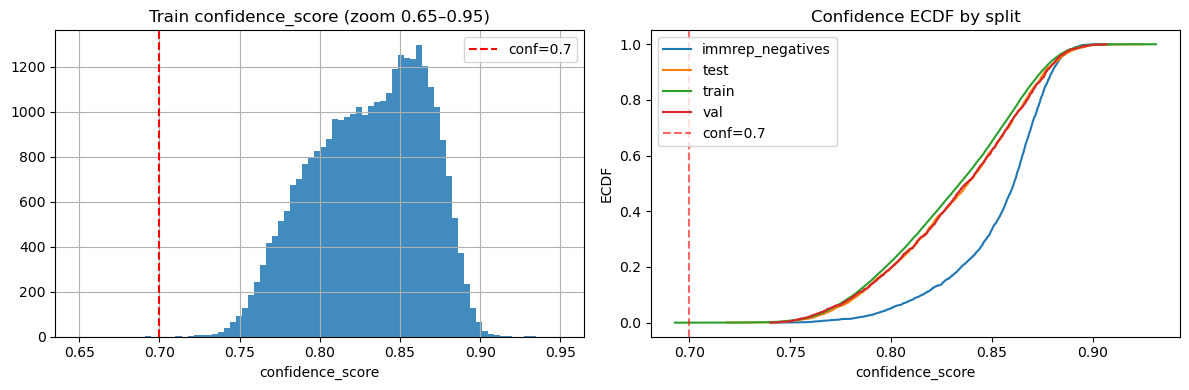

train confidence < 0.8: 6834 (21.9%)


In [49]:
# Where does the train tail come from? (zoom + ECDF)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left tail zoom for confidence_score
ax = axes[0]
train_m["confidence_score"].hist(bins=80, range=(0.65, 0.95), ax=ax, alpha=0.85)
ax.axvline(THRESHOLD_CONF, color="red", ls="--", label=f"conf={THRESHOLD_CONF}")
ax.set_xlabel("confidence_score")
ax.set_title("Train confidence_score (zoom 0.65–0.95)")
ax.legend()

# ECDF vs other splits
ax = axes[1]
for split, sub in df_scores.groupby("split"):
    x = np.sort(sub["confidence_score"].dropna())
    y = np.arange(1, len(x) + 1) / len(x)
    ax.plot(x, y, label=split)
ax.axvline(THRESHOLD_CONF, color="red", ls="--", alpha=0.6, label=f"conf={THRESHOLD_CONF}")
ax.set_xlabel("confidence_score")
ax.set_ylabel("ECDF")
ax.set_title("Confidence ECDF by split")
ax.legend()
plt.tight_layout()
plt.show()

# ~22% of train below 0.8 (the visible left tail in full histogram)
print(f"train confidence < 0.8: {(train_m.confidence_score < 0.8).sum()} ({100*(train_m.confidence_score < 0.8).mean():.1f}%)")

tail (<0.8): 6834 | ok (>=0.8): 24339


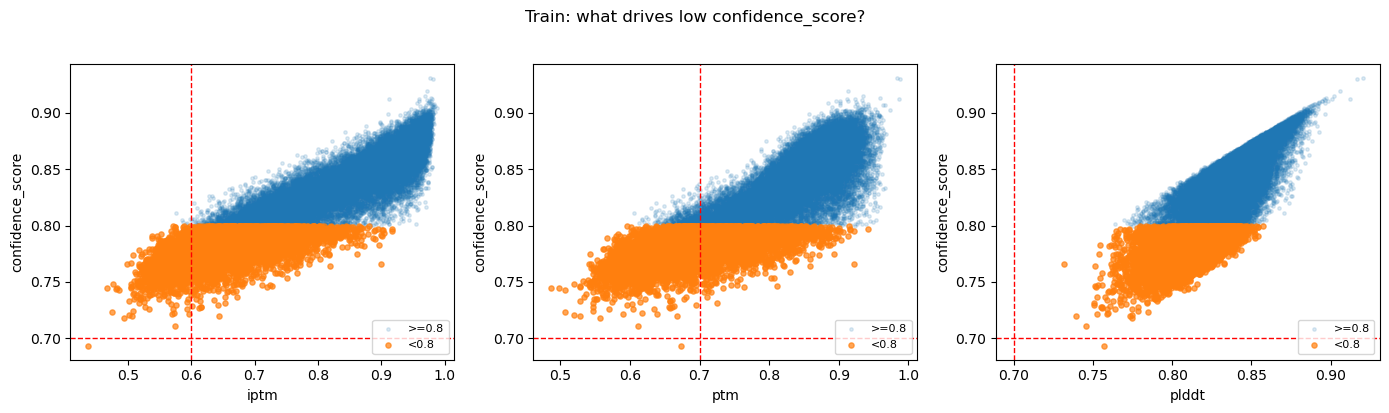

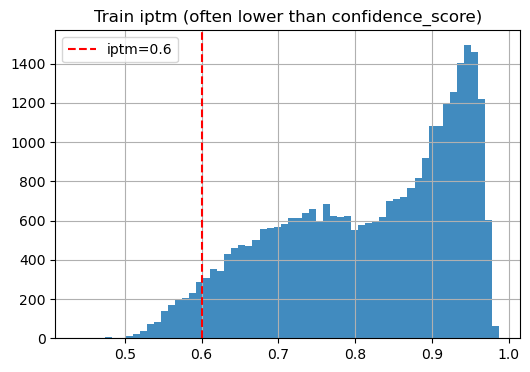

In [50]:
# Metric relationships in train tail
tail = train_m[train_m["confidence_score"] < 0.8].copy()
ok = train_m[train_m["confidence_score"] >= 0.8].copy()
print(f"tail (<0.8): {len(tail)} | ok (>=0.8): {len(ok)}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, x, y in zip(
    axes,
    ["iptm", "ptm", "plddt"],
    ["confidence_score", "confidence_score", "confidence_score"],
):
    ax.scatter(ok[x], ok[y], s=6, alpha=0.15, label=">=0.8")
    ax.scatter(tail[x], tail[y], s=14, alpha=0.7, label="<0.8")
    ax.axhline(metric_threshold(y), color="red", ls="--", lw=1)
    ax.axvline(metric_threshold(x), color="red", ls="--", lw=1)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.legend(loc="lower right", fontsize=8)
plt.suptitle("Train: what drives low confidence_score?", y=1.02)
plt.tight_layout()
plt.show()

# Low iptm is common even when confidence looks fine
fig, ax = plt.subplots(figsize=(6, 4))
train_m["iptm"].hist(bins=60, ax=ax, alpha=0.85)
ax.axvline(THRESHOLD_IPTM, color="red", ls="--", label=f"iptm={THRESHOLD_IPTM}")
ax.set_title("Train iptm (often lower than confidence_score)")
ax.legend()
plt.show()

,n,confidence_score,iptm,ptm,plddt
tcr_status,,,,,
both_present,26928,0.835,0.819,0.811,0.839
tcra_missing,1003,0.805,0.791,0.806,0.809
tcrb_missing,3223,0.806,0.795,0.812,0.808


/tmp/ipykernel_989010/1151631035.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)
/tmp/ipykernel_989010/1151631035.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)
/tmp/ipykernel_989010/1151631035.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)
/tmp/ipykernel_989010/1151631035.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.box

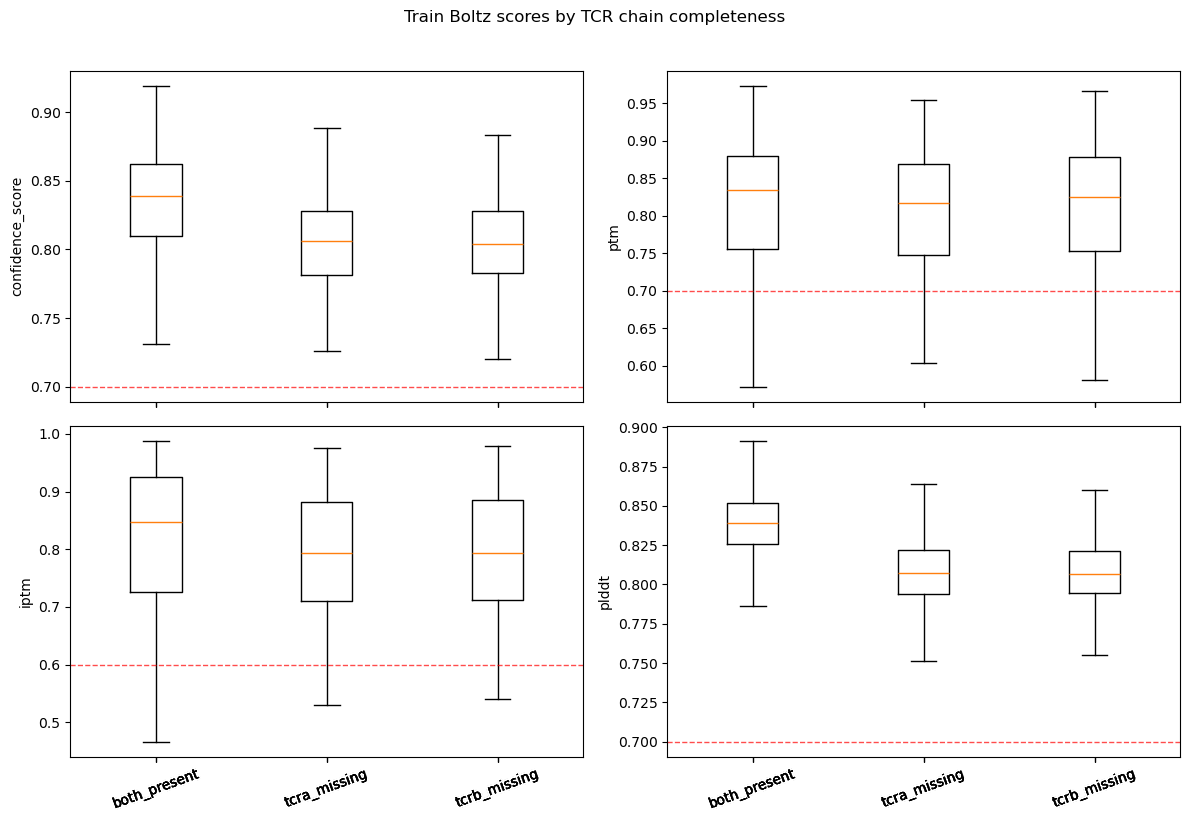

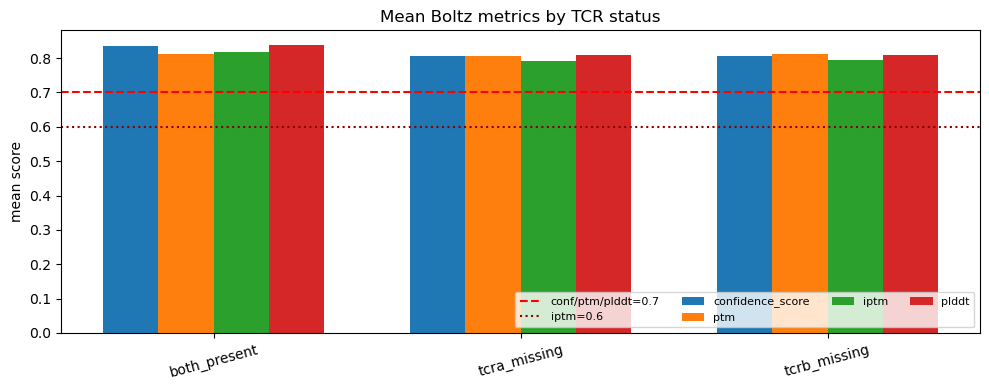

,n,confidence_score_lt_0.7,ptm_lt_0.7,iptm_lt_0.6,plddt_lt_0.7
tcr_status,,,,,
both_present,26928,0.000,0.143,0.049,0.0
tcra_missing,1003,0.001,0.123,0.019,0.0
tcrb_missing,3223,0.000,0.108,0.016,0.0


Wrote /home/natasha/multimodal_model/scripts/analysis/train_low_confidence_lt0.8.csv


In [51]:
# TCR chain completeness vs Boltz scores (train)
feat_cols = ["pep_len", "tcra_len", "tcrb_len", "hla_len"]
plot_df = train_m.dropna(subset=feat_cols + METRICS).copy()
plot_df["missing_tcra"] = plot_df["tcra_len"] == 0
plot_df["missing_tcrb"] = plot_df["tcrb_len"] == 0

def tcr_status(row) -> str:
    if row["missing_tcra"] and row["missing_tcrb"]:
        return "both_missing"
    if row["missing_tcra"]:
        return "tcra_missing"
    if row["missing_tcrb"]:
        return "tcrb_missing"
    return "both_present"

plot_df["tcr_status"] = plot_df.apply(tcr_status, axis=1)
STATUS_ORDER = ["both_present", "tcra_missing", "tcrb_missing", "both_missing"]
plot_df["tcr_status"] = pd.Categorical(plot_df["tcr_status"], categories=STATUS_ORDER, ordered=True)

# Summary table
summary = (
    plot_df.groupby("tcr_status", observed=True)
    .agg(
        n=("pair_id", "count"),
        confidence_score=("confidence_score", "mean"),
        iptm=("iptm", "mean"),
        ptm=("ptm", "mean"),
        plddt=("plddt", "mean"),
    )
    .round(3)
)
display(summary)

# Boxplots: all four metrics × combined TCR status
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, metric in zip(axes.ravel(), METRICS):
    groups = [plot_df.loc[plot_df["tcr_status"] == s, metric].dropna().values for s in STATUS_ORDER]
    labels = [s for s, g in zip(STATUS_ORDER, groups) if len(g) > 0]
    data = [g for g in groups if len(g) > 0]
    ax.boxplot(data, labels=labels, showfliers=False)
    ax.axhline(metric_threshold(metric), color="red", ls="--", lw=1, alpha=0.7)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=20)
fig.suptitle("Train Boltz scores by TCR chain completeness", y=1.02)
plt.tight_layout()
plt.show()

# Mean scores bar chart (easier to compare degradation)
means = summary[["confidence_score", "iptm", "ptm", "plddt"]]
x = np.arange(len(means))
width = 0.18
fig, ax = plt.subplots(figsize=(10, 4))
for i, metric in enumerate(METRICS):
    ax.bar(x + (i - 1.5) * width, means[metric], width=width, label=metric)
ax.set_xticks(x)
ax.set_xticklabels(means.index, rotation=15)
ax.axhline(THRESHOLD_CONF, color="red", ls="--", label=f"conf/ptm/plddt={THRESHOLD_CONF}")
ax.axhline(THRESHOLD_IPTM, color="darkred", ls=":", label=f"iptm={THRESHOLD_IPTM}")
ax.set_ylabel("mean score")
ax.set_title("Mean Boltz metrics by TCR status")
ax.legend(ncol=4, fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

# Fraction below threshold per status
frac_rows = []
for status in STATUS_ORDER:
    sub = plot_df[plot_df["tcr_status"] == status]
    if len(sub) == 0:
        continue
    row = {"tcr_status": status, "n": len(sub)}
    for metric in METRICS:
        thr = metric_threshold(metric)
        row[f"{metric}_lt_{thr}"] = (sub[metric] < thr).mean()
    frac_rows.append(row)
display(pd.DataFrame(frac_rows).set_index("tcr_status").round(3))

# Export tail for manual follow-up
out = BASE / "scripts/analysis/train_low_confidence_lt0.8.csv"
train_m.loc[train_m["confidence_score"] < 0.8].sort_values("confidence_score").to_csv(out, index=False)
print(f"Wrote {out}")